# Statistical Arbitrage Baseline

This compact notebook reproduces the transparent first baseline. The full repository contains the tested research implementation.

In [1]:
import os, pathlib, subprocess, sys
if 'google.colab' in sys.modules:
    subprocess.run(['git', 'clone', 'https://github.com/am610/regime-aware-statistical-arbitrage.git'], check=True)
    os.chdir('regime-aware-statistical-arbitrage')
else:
    root = pathlib.Path.cwd().resolve()
    while root != root.parent and not (root / 'pyproject.toml').exists():
        root = root.parent
    if not (root / 'pyproject.toml').exists():
        raise RuntimeError('Run this notebook from inside the project folder')
    os.chdir(root)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-e', '.'], check=True)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
numba 0.57.1 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.


CompletedProcess(args=['/Users/ayan/anaconda3/bin/python', '-m', 'pip', 'install', '-q', '-e', '.'], returncode=0)

## Run the untouched test period experiment

The hedge relation is estimated on the training period. Signals use only information available at that time, and target weights are applied one observation later.

In [2]:
subprocess.run([sys.executable, 'scripts/run_pair_baseline.py'], check=True)

Matplotlib is building the font cache; this may take a moment.
/Users/ayan/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
findfont: Failed to find font weight medium, now using 400.


{
  "symbols": [
    "XLE",
    "XOP"
  ],
  "retrieval_end": "2026-08-24",
  "train_start": "2012-01-03",
  "train_end": "2020-10-09",
  "validation_start": "2020-10-12",
  "validation_end": "2023-09-14",
  "test_start": "2023-09-15",
  "test_end": "2026-08-21",
  "hedge_ratio": 2.1256949932991818,
  "validation": {
    "annual_return": -0.031076401618035265,
    "annual_volatility": 0.06163461662808292,
    "sharpe_ratio": -0.4814084188537843,
    "sortino_ratio": -0.4959454097337874,
    "maximum_drawdown": -0.15414540942988886,
    "ending_wealth": 0.9119199827490456,
    "positive_period_fraction": 0.19021739130434784
  },
  "test": {
    "annual_return": 0.013382010313651271,
    "annual_volatility": 0.05015887179918835,
    "sharpe_ratio": 0.2900205906111438,
    "sortino_ratio": 0.2894389047409426,
    "maximum_drawdown": -0.0940428178443452,
    "ending_wealth": 1.039588295920701,
    "positive_period_fraction": 0.18478260869565216
  },
  "test_sharpe_interval_95": [
    -0.95

CompletedProcess(args=['/Users/ayan/anaconda3/bin/python', 'scripts/run_pair_baseline.py'], returncode=0)

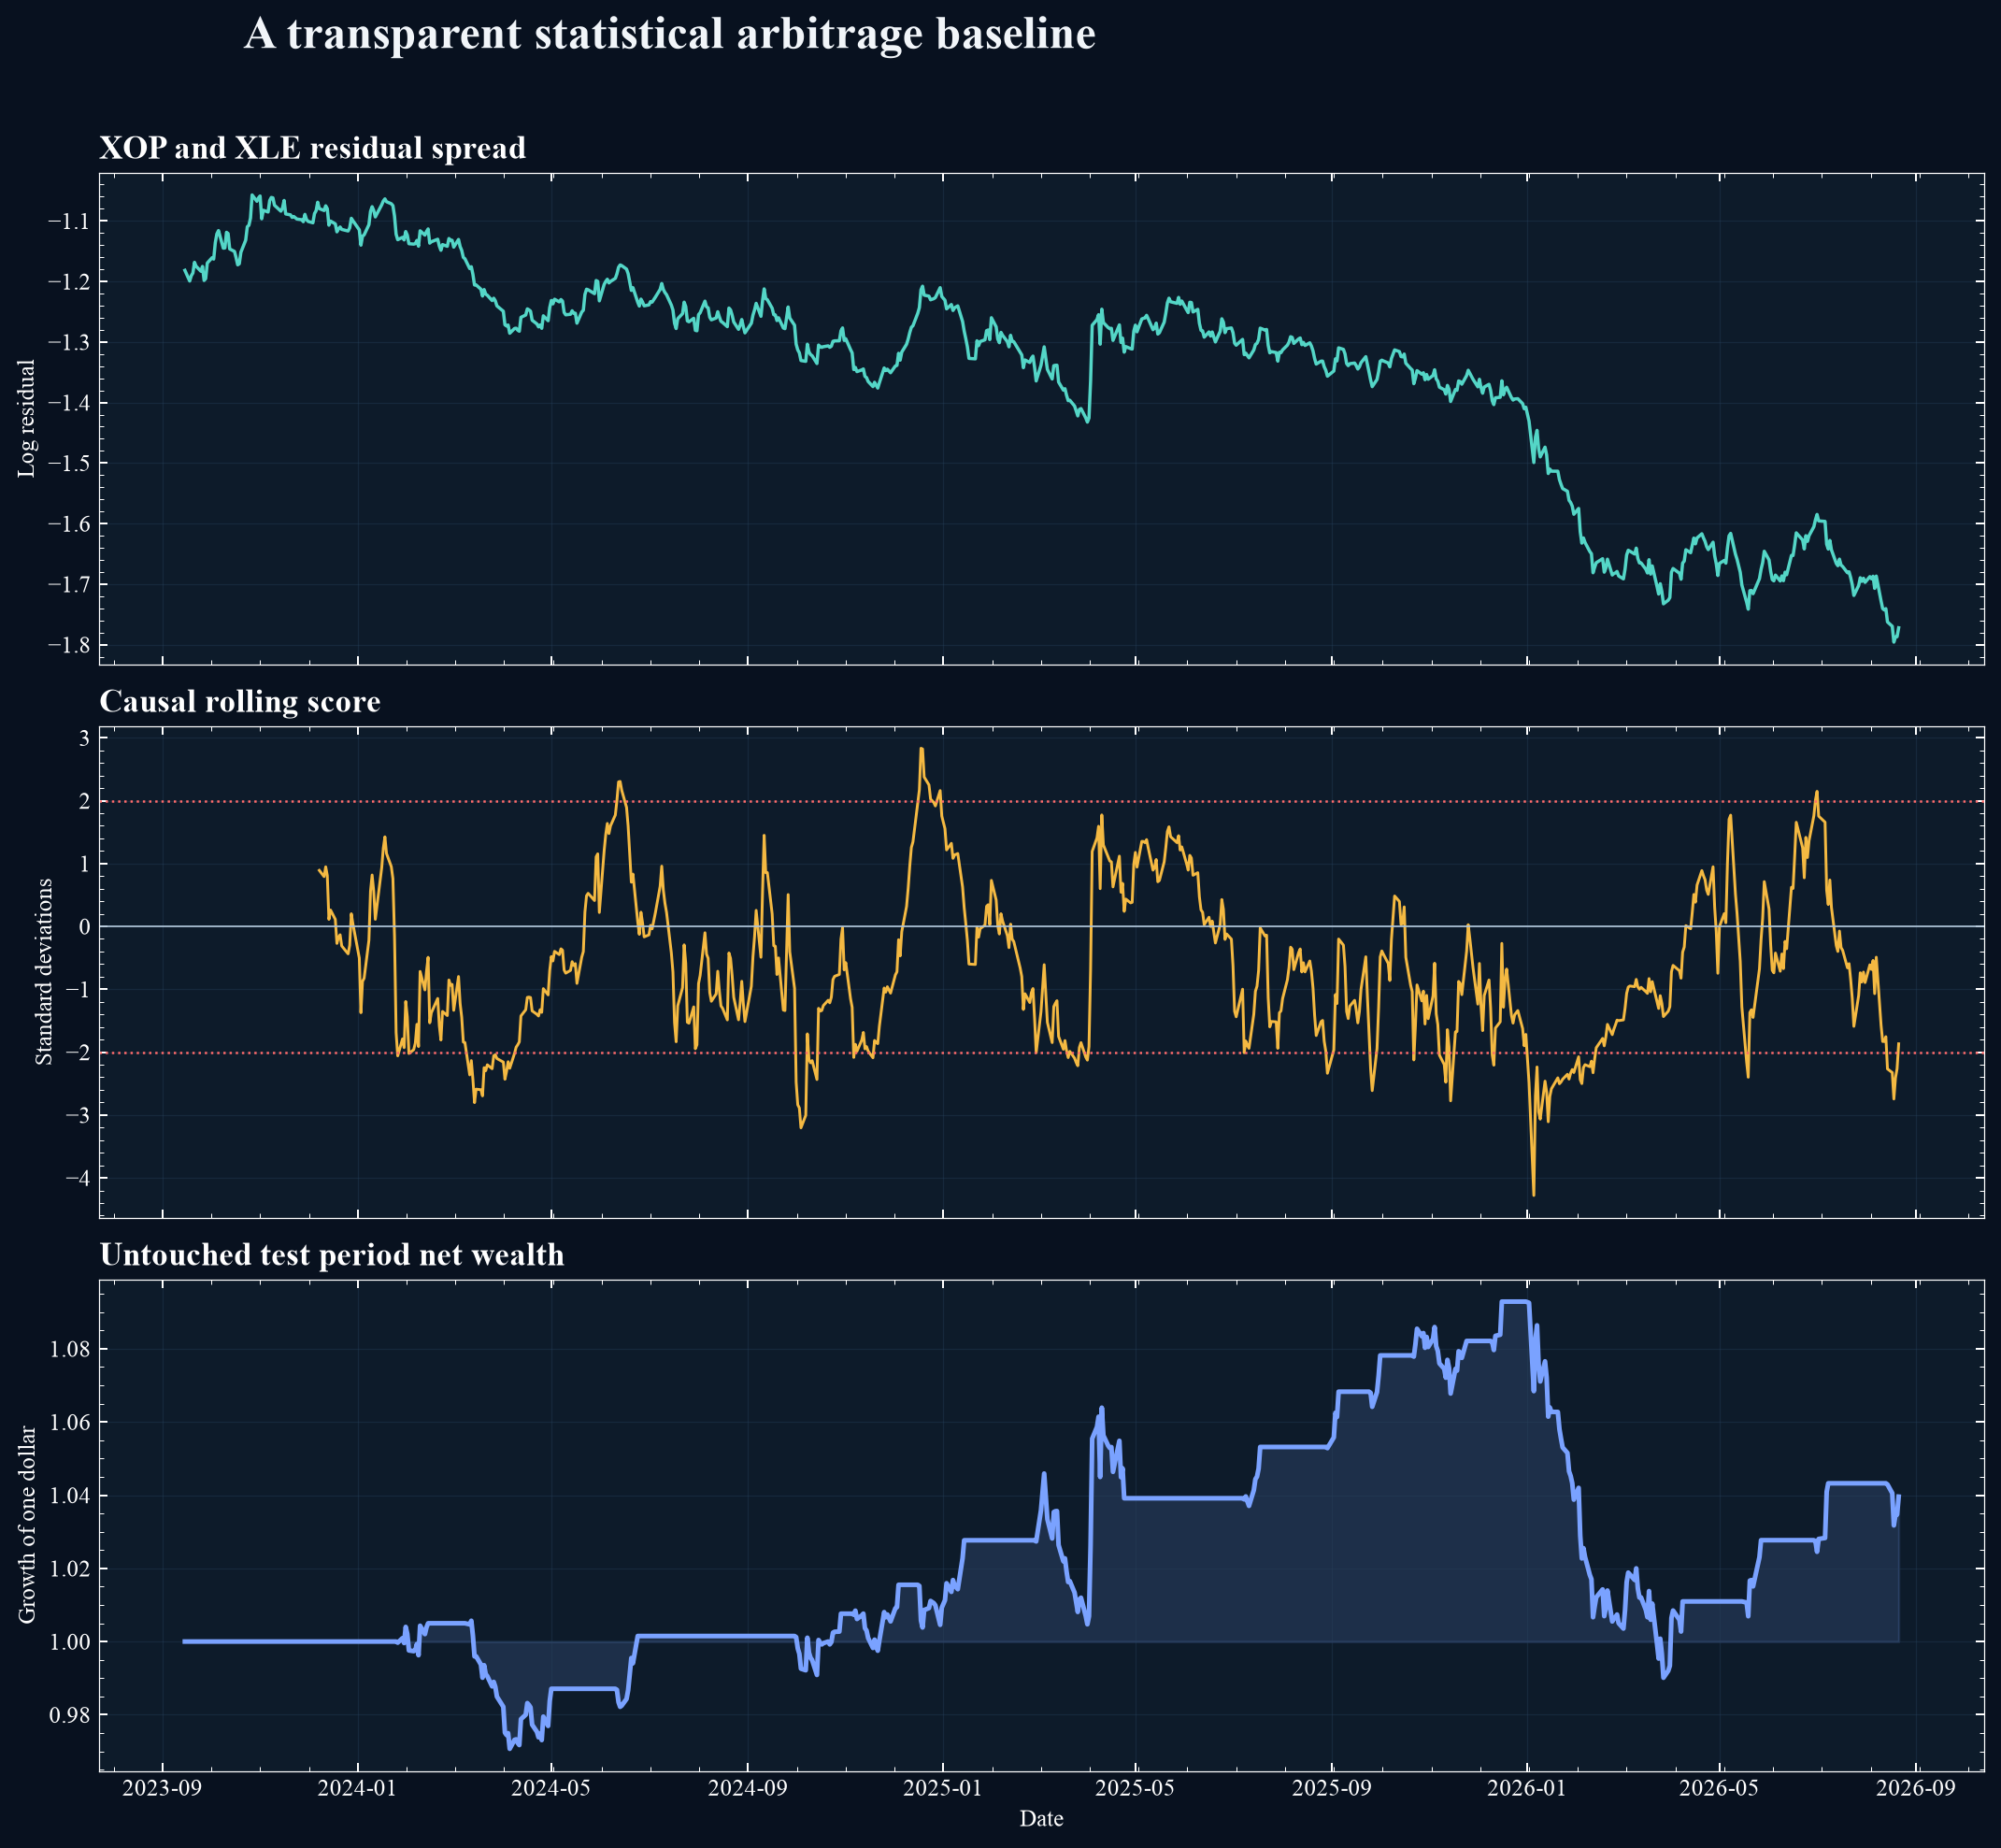

In [3]:
from IPython.display import Image, display
display(Image(filename='docs/assets/pair_baseline.png'))